In [2]:
# ============================================================================
# IMPORTS AND SETUP
# ============================================================================
# Data manipulation and visualization libraries
import pandas as pd      
import numpy as np         
import utils                    
import seaborn as sns          
from matplotlib import rcParams  
import matplotlib.pyplot as plt   
from tqdm import tqdm            
from scipy import stats        
from importlib import reload     
import matplotlib.ticker as ticker 

# Configure figure styling for publication quality
utils.set_figure_style(scale="1col")  # Set figure dimensions and fonts
sns.set_palette("colorblind")         # Use colorblind-friendly palette

# Ariani's Repetition Experiment (Ariani et al. 2020)


In [3]:
# ============================================================================
# DATA LOADING - Ariani et al. 2020 Multi-Sequence Repetition Experiment
# ============================================================================
# Experimental parameters
num_seqs = 8                        # Number of different sequences trained
total_sub_num = 38                  # Number of subjects
num_sessions = 2                    # Training sessions (Day 1, Day 2)
num_blocks_per_session = 12         # Blocks per session
num_trials_per_block = 50           # Trials per block

# Load force data: contains trial-by-trial force patterns
forces = pd.read_csv('./Data/Ariani_Multi_Seq_Forces.csv')

# Create force_vector column: concatenate individual force measurements into arrays
# This enables vectorized distance calculations between trials
forces['force_vector'] = forces[[col for col in forces.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)

# Load subject-level data: contains behavioral metrics (execution time, errors, etc.)
subjs = pd.read_csv('./Data/Ariani_Multi_Seq_Subjs.csv')

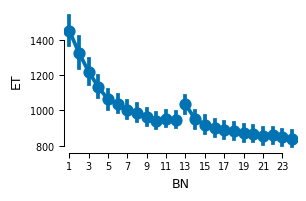

In [4]:
# ============================================================================
# EXECUTION TIME (ET) ACROSS LEARNING
# ============================================================================
# Calculate median execution time per subject, block, and day
# ET is the time to execute the full sequence
grouped_subjs = subjs.groupby(['SubNum', 'BN', 'day']).agg({'ET': 'median'}).reset_index()

# Plot ET across blocks, separated by day
for day, day_group in grouped_subjs.groupby('day'):
    sns.pointplot(data=day_group, x='BN', y='ET', errorbar='se', 
                  color=sns.color_palette("colorblind")[0])

# Customize x-axis to show every 2nd block number (reduce clutter)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine(trim=True)

In [5]:
# ============================================================================
# FORCE PATTERN DISTANCE ANALYSIS
# ============================================================================
# Calculate pairwise Euclidean distances between force patterns
# This reveals how force patterns change across trials and sequences

forces_correct = utils.remove_error_trials(forces)  # Exclude error trials

distances = []

# Iterate through all subjects
for subind, subdata in tqdm(forces_correct.groupby('SubNum')):
    # For each subject, analyze each sequence separately
    for seq, seqdata in subdata.groupby('seqNum'):
        # Stack all force vectors into a 2D array (trials x force_dimensions)
        X = np.vstack(seqdata['force_vector'].to_numpy())
        Y = seqdata['ET'].to_numpy()          # Execution times
        trials = seqdata['N'].to_numpy()      # Trial numbers
        blocks = seqdata['BN'].to_numpy()     # Block numbers
        n = len(seqdata)
        
        # Upper triangular indices for pairwise comparisons (avoid redundant comparisons)
        i, j = np.triu_indices(n, k=1)

        # Calculate pairwise distances: Euclidean distance in force space
        force_dist = np.linalg.norm(X[i] - X[j], axis=1)
        trial_dist = np.abs(trials[i] - trials[j])      # How many trials apart
        et_dist = Y[i] - Y[j]                           # Execution time difference
        block_dist = np.abs(blocks[i] - blocks[j])      # How many blocks apart

        distances.append(pd.DataFrame({
            'SubNum': subind,
            'seqNum': seq,
            'Trial1': trials[i],
            'Trial2': trials[j],
            'Force_Distance': force_dist,
            'Trial_Distance': trial_dist,
            'ET_Distance': et_dist,
            'Block_Distance': block_dist,
            'abs_ET_Distance': np.abs(et_dist),
            'first_trial_ET': Y[i],
            'second_trial_ET': Y[j]
        }))

# Consolidate all distances into a single DataFrame
distances_df = pd.concat(distances, ignore_index=True)

100%|██████████| 38/38 [00:10<00:00,  3.66it/s]


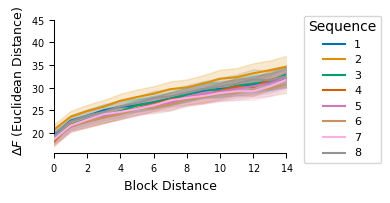

In [6]:
# ============================================================================
# FORCE PATTERN DISTANCES ACROSS BLOCK DISTANCES
# ============================================================================
# Group distances by block separation to see how force patterns change
grouped_distances = distances_df.groupby(['SubNum', 'Block_Distance', 'seqNum']).agg({'Force_Distance': 'median'}).reset_index()

# Plot median force distance vs block separation, colored by sequence
sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', 
             errorbar='se', hue='seqNum', palette='colorblind')

plt.xlabel('Block Distance')
plt.ylabel(r'$\Delta F$ (Euclidean Distance)')

plt.legend(title='Sequence', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlim(0, 14)
sns.despine(trim=True)

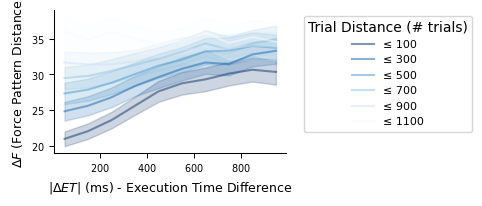

In [7]:
# ============================================================================
# FORCE PATTERN DISTANCES ACROSS EXECUTION TIME DIFFERENCES
# ============================================================================
# Investigate whether force patterns are similar when execution times are similar
# This decouples learning effects from speed effect

ET_diff_bin_size = 100       # Bin ET differences into 100ms windows
trial_distance_bin = 200     # Bin trial numbers into 200-trial windows
distances_df = distances_df.copy()
distances_df['count'] = 1
distances_df['ET_Distance'] = np.abs(distances_df['ET_Distance'])

# Filter data: only consider trials within 1 second and force distances < 60
distances_df = distances_df[distances_df['ET_Distance'] < 1000]
distances_df = distances_df[distances_df['Force_Distance'] < 60]

# Create binned columns for easier visualization and averaging
distances_df['ET_diff_bin'] = distances_df['ET_Distance'] // ET_diff_bin_size * ET_diff_bin_size + ET_diff_bin_size // 2
distances_df['trial_distance_bin'] = distances_df['Trial_Distance'] // trial_distance_bin * trial_distance_bin + trial_distance_bin // 2

# Group by subject and bins, calculate median force distance
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'trial_distance_bin']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

# Plot: force distance depends on both execution time similarity and trial separation
sns.lineplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', 
             errorbar='se', alpha=0.5, hue='trial_distance_bin', palette='Blues_r')

plt.xlabel(r'$|\Delta ET|$ (ms) - Execution Time Difference')
plt.ylabel(r'$\Delta F$ (Force Pattern Distance)')

# Reformat legend labels
handles, labels = plt.gca().get_legend_handles_labels()
formatted_labels = [
    f'≤ {label}' if label != 'Trial Distance' else label
    for label in labels
]
plt.legend(handles, formatted_labels, title='Trial Distance (# trials)',
           bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()

## Repetition Analysis

In [8]:
# ============================================================================
# EXECUTION TIME CHANGES ACROSS REPETITIONS
# ============================================================================
# In the multi-sequence task, subjects repeat sequences multiple times
# This analyzes how execution time changes with repetition number

ET_diffs = []
for subind, subdata in subjs.groupby('SubNum'):
    for bn, bndata in subdata.groupby('BN'):  # Within each block
        for i in range(len(bndata)):
            trial = bndata.iloc[i]
            rep = int(trial['repNum'])                 # Which repetition is this trial?
            first_rep_idx = i - (rep - 1)              # Index of first repetition of this sequence
            first_rep_trial = bndata.iloc[first_rep_idx]
            
            # Skip if any trial between first and current is an error)
            if bndata.iloc[first_rep_idx:i+1]['isError'].any():
                continue
            
            # Calculate execution time change from first repetition
            et_diff = trial['ET'] - first_rep_trial['ET']
            ET_diffs.append({
                'SubNum': subind,
                'BN': bn,
                'TN': int(trial['TN']),               # Trial number
                'repNum': rep,                         # Repetition number
                'et_diff': et_diff,                    # Speed change from 1st rep
                'seqNum': int(trial['seqNum']),
                'day': int(trial['day'])
            })

ET_diffs_df = pd.DataFrame(ET_diffs)

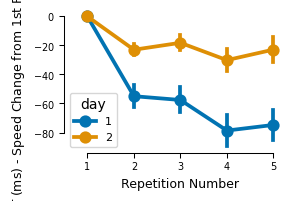

In [9]:
# ============================================================================
# PLOT: EXECUTION TIME CHANGE vs REPETITION NUMBER
# ============================================================================

ET_diffs_grouped = ET_diffs_df.groupby(['SubNum', 'repNum', 'day']).agg({'et_diff': 'median'}).reset_index()
sns.pointplot(data=ET_diffs_grouped, x='repNum', y='et_diff', 
              errorbar='se', hue='day', palette='colorblind')

plt.xlabel('Repetition Number')
plt.ylabel(r'$\Delta ET$ (ms) - Speed Change from 1st Repetition')

sns.despine(trim=True)

In [10]:
# ============================================================================
# FORCE PATTERN CHANGES WITHIN vs BETWEEN REPETITION BOUTS
# ============================================================================
# A "bout" is a continuous trials of successful (non-error) repetitions
# This analyzes how force patterns change within bouts and across bouts
# Hypothesis: Can we see forgetting and/or recalibration across bouts?

force_diffs = []

# WITHIN-BOUT ANALYSIS: Compare force patterns between consecutive successful repetitions
for subind, subdata in tqdm(forces.groupby('SubNum')):
    for bn, bndata in subdata.groupby('BN'):
        for seq, seqdata in bndata.groupby('seqNum'):
            for i in range(len(seqdata)):
                trial = seqdata.iloc[i]
                rep = int(trial['repNum'])
                if trial['isError'] == 1:
                    continue
                
                # Find trials after this one that are still in the same bout
                for j in range(i+1, len(seqdata)):
                    trial_j = seqdata.iloc[j]
                    if trial_j['isError'] == 1:        # End of bout
                        break
                    if trial_j['repNum'] == 1:         # New bout started
                        break
                    
                    # Calculate force pattern distance within bout
                    et_diff = trial_j['ET'] - trial['ET']
                    force_dist = np.linalg.norm(trial_j['force_vector'] - trial['force_vector'])
                    force_diffs.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'ET_Distance': et_diff,
                        'trial1_repNum': rep,
                        'trial1_repType': trial['repType'],
                        'trial2_repNum': int(trial_j['repNum']),
                        'trial2_repType': trial_j['repType'],
                        'type': 'within_bout',
                        'seqNum': int(trial['seqNum']),
                        'day': int(trial['day']),
                        'length_of_bout': int(trial['repType'])
                    })

# BETWEEN-BOUT ANALYSIS: Compare force patterns across bout boundaries
for subind, subdata in tqdm(forces.groupby('SubNum')):
    for bn, bndata in subdata.groupby('BN'):
        for seq, seqdata in bndata.groupby('seqNum'):
            for i in range(len(seqdata)):
                trial = seqdata.iloc[i]
                rep = int(trial['repNum'])
                if trial['isError'] == 1:
                    continue

                new_bout = False
                length_of_bout = 0
                for j in range(i+1, len(seqdata)):
                    trial_j = seqdata.iloc[j]
                    
                    # Detect the start of a new bout (repNum reset to 1)
                    if (trial_j['repNum'] == 1) and (not new_bout):
                        new_bout = True
                        length_of_bout = seqdata.iloc[j-1]['repNum']  # Length of previous bout

                    # Stop when we reach another new bout
                    elif (trial_j['repNum'] == 1) and new_bout:
                        break

                    if new_bout:
                        if trial_j['isError'] == 1:
                            break
                        
                        # Calculate force pattern distance between bouts
                        et_diff = trial_j['ET'] - trial['ET']
                        force_dist = np.linalg.norm(trial_j['force_vector'] - trial['force_vector'])
                        force_diffs.append({
                            'SubNum': subind,
                            'Force_Distance': force_dist,
                            'ET_Distance': et_diff,
                            'trial1_repNum': rep,
                            'trial1_repType': trial['repType'],
                            'trial2_repNum': int(trial_j['repNum']),
                            'trial2_repType': trial_j['repType'],
                            'type': 'between_bout',
                            'seqNum': int(trial['seqNum']),
                            'day': int(trial['day']),
                            'length_of_bout': length_of_bout
                        })

force_diffs_df = pd.DataFrame(force_diffs)

100%|██████████| 38/38 [00:47<00:00,  1.26s/it]


Text(0.5, 1.0, 'Force Pattern Distance: Within vs Between Repetition Bouts ($||\\Delta F||$)')

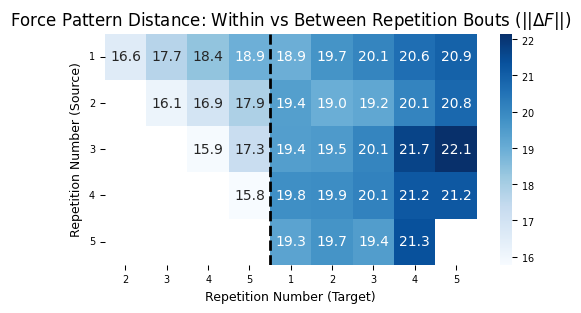

In [12]:
# ============================================================================
# FORCE DISTANCES WITHIN vs BETWEEN BOUTS
# ============================================================================
# Visualize how force patterns change based on repetition transitions
# Rows: repetition number at start
# Columns: repetition number at end (separated into within-bout and between-bout)

force_diffs_df['count'] = 1

# Aggregate: median force distance by comparison type
grouped_distances = force_diffs_df.groupby(['SubNum', 'trial1_repNum', 'trial2_repNum', 'type']).agg({
    'Force_Distance': 'median', 
    'count': 'sum'
}).reset_index()

# Average across subjects
grouped_distances = grouped_distances.groupby(['trial1_repNum', 'trial2_repNum', 'type']).agg({
    'Force_Distance': 'mean'
}).reset_index()

# Create pivot table for heatmap
heatmap_data = grouped_distances.pivot_table(index='trial1_repNum', columns=['trial2_repNum', 'type'], values='Force_Distance')

# Sort columns so within-bout comparisons appear before between-bout
heatmap_data = heatmap_data.reindex(columns=sorted(heatmap_data.columns, key=lambda x: (0 if x[1]=='within_bout' else 1, x[0])))

plt.figure(figsize=(6, 3))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='Blues')

# Customize axis labels to show only repetition numbers
plt.xticks(ticks=[i + 0.5 for i in range(len(heatmap_data.columns))], 
           labels=[col[0] for col in heatmap_data.columns], rotation=0)
plt.yticks(ticks=[i + 0.5 for i in range(len(heatmap_data.index))], 
           labels=heatmap_data.index, rotation=0)

# Add vertical line separating within-bout and between-bout columns
num_reps = len(heatmap_data.index)
plt.axvline(x=num_reps-1, color='black', linestyle='--', linewidth=2)

plt.xlabel('Repetition Number (Target)')
plt.ylabel('Repetition Number (Source)')
plt.title(r'Force Pattern Distance: Within vs Between Repetition Bouts ($||\Delta F||$)')